# **Day 71: Autoencoders and Variational Autoencoders (VAEs)**
*Module 11 - Advanced Deep Learning*

An **autoencoder** compresses its input into a small **latent code** and reconstructs it. Because it must squeeze information through a bottleneck, it learns the main structure of the data: useful for dimensionality reduction, denoising, anomaly detection and as a building block of generative models. The **VAE** turns the autoencoder into a proper **probabilistic generative model** that can create new samples.

> An autoencoder compresses data into a small code and reconstructs it, learning the essential structure. A variational autoencoder makes this code probabilistic, so it can also generate new, realistic samples.
>
> *Example:* An autoencoder trained on clear-sky spectra reconstructs cloudy pixels poorly, and that high error can flag them as anomalies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
torch.manual_seed(71); rng = np.random.default_rng(71)

X, y = load_digits(return_X_y=True); X = (X / 16.0).astype(np.float32)
X_tr, y_tr, X_te, y_te = X[:1400], y[:1400], X[1400:], y[1400:]
dl = DataLoader(TensorDataset(torch.tensor(X_tr)), batch_size=64, shuffle=True)

## **1. An Undercomplete Autoencoder**
Encoder $\mathbf z = f(\mathbf x)$ with $\dim(\mathbf z)\ll\dim(\mathbf x)$; decoder $\hat{\mathbf x} = g(\mathbf z)$; minimise $\lVert\mathbf x - \hat{\mathbf x}\rVert^2$. A **linear** autoencoder with MSE learns the same subspace as PCA; non-linear ones can capture curved manifolds.

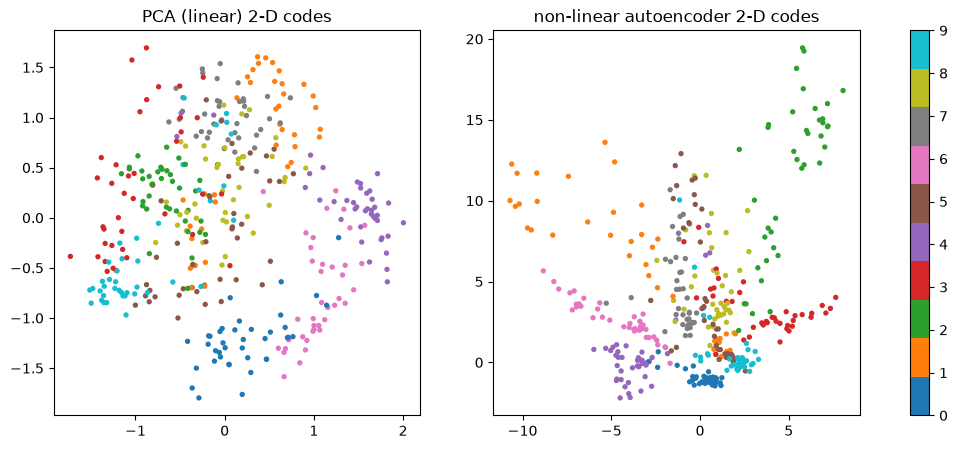

latent dim  2: reconstruction MSE  PCA 0.0523 | autoencoder 0.0361


latent dim  8: reconstruction MSE  PCA 0.0250 | autoencoder 0.0157


latent dim 16: reconstruction MSE  PCA 0.0123 | autoencoder 0.0123


In [2]:
class AE(nn.Module):
    def __init__(self, d_in=64, d_z=2, h=128):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h // 2), nn.ReLU(), nn.Linear(h // 2, d_z))
        self.dec = nn.Sequential(nn.Linear(d_z, h // 2), nn.ReLU(), nn.Linear(h // 2, h), nn.ReLU(), nn.Linear(h, d_in), nn.Sigmoid())
    def forward(self, x): z = self.enc(x); return self.dec(z), z

def train_ae(model, epochs=150, lr=2e-3, noise=0.0):
    opt = torch.optim.Adam(model.parameters(), lr)
    for ep in range(epochs):
        for (xb,) in dl:
            inp = (xb + noise * torch.randn_like(xb)).clamp(0, 1) if noise else xb
            rec, _ = model(inp); loss = F.mse_loss(rec, xb); opt.zero_grad(); loss.backward(); opt.step()
    return model

ae2 = train_ae(AE(d_z=2))
with torch.no_grad(): Z_ae = ae2.enc(torch.tensor(X_te)).numpy()
Z_pca = PCA(2).fit(X_tr).transform(X_te)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, t in [(axes[0], Z_pca, "PCA (linear) 2-D codes"), (axes[1], Z_ae, "non-linear autoencoder 2-D codes")]:
    sc = ax.scatter(*Z.T, c=y_te, cmap="tab10", s=8); ax.set_title(t)
fig.colorbar(sc, ax=axes); plt.show()

for d_z in [2, 8, 16]:
    ae = train_ae(AE(d_z=d_z), epochs=100); pca = PCA(d_z).fit(X_tr)
    with torch.no_grad(): err_ae = F.mse_loss(ae(torch.tensor(X_te))[0], torch.tensor(X_te)).item()
    err_pca = np.mean((pca.inverse_transform(pca.transform(X_te)) - X_te) ** 2)
    print(f"latent dim {d_z:>2}: reconstruction MSE  PCA {err_pca:.4f} | autoencoder {err_ae:.4f}")

## **2. Denoising Autoencoders**
Train with **corrupted** inputs and **clean** targets: the network must learn the data manifold to remove the noise (Vincent et al., 2008).

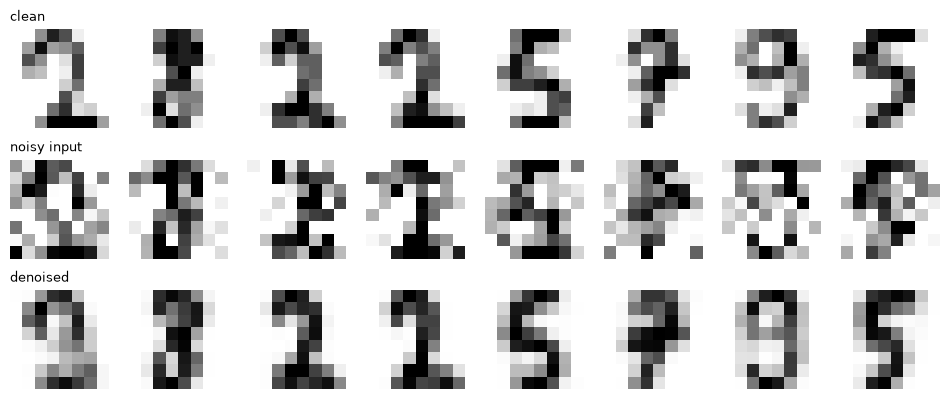

In [3]:
dae = train_ae(AE(d_z=16), noise=0.35)
noisy = (torch.tensor(X_te[:8]) + 0.35 * torch.randn(8, 64)).clamp(0, 1)
with torch.no_grad(): den = dae(noisy)[0]
fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
for j in range(8):
    for i, img in enumerate([X_te[j], noisy[j], den[j]]):
        axes[i, j].imshow(np.asarray(img).reshape(8, 8), cmap="gray_r"); axes[i, j].axis("off")
for i, t in enumerate(["clean", "noisy input", "denoised"]): axes[i, 0].set_title(t, loc="left", fontsize=9)
plt.show()

## **3. Anomaly Detection by Reconstruction Error**
Train only on "normal" data. Unusual inputs reconstruct poorly. Example: spectra of healthy vegetation pixels vs anomalies (burnt, flooded, cloud-contaminated).

anomaly detection ROC-AUC by reconstruction error: 1.000


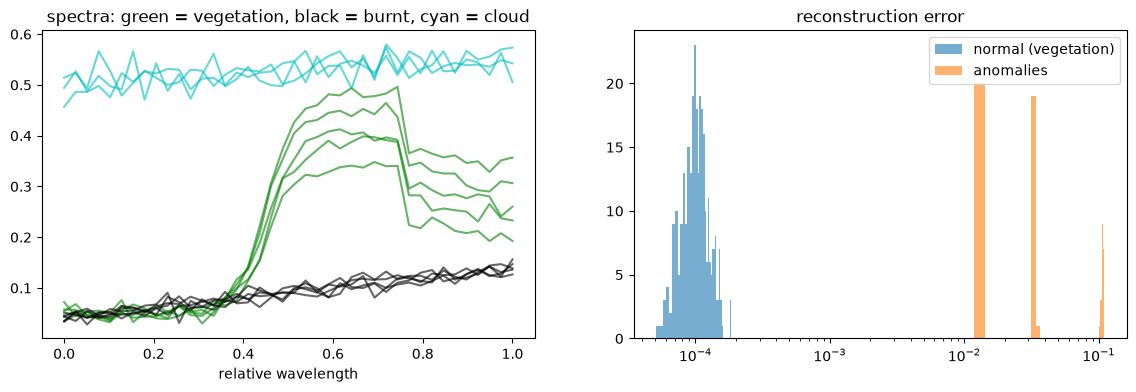

In [4]:
wl = np.linspace(0, 1, 40)
def veg(n):  return (0.05 + 0.4 / (1 + np.exp(-(wl - 0.45) * 30)) * rng.uniform(0.7, 1.2, (n, 1)) - 0.15 * wl * (wl > 0.75) + rng.normal(0, 0.01, (n, 40))).astype(np.float32)
def burnt(n): return (0.04 + 0.1 * wl + rng.normal(0, 0.01, (n, 40))).astype(np.float32)
def water(n): return (0.08 * np.exp(-wl * 5) + rng.normal(0, 0.005, (n, 40))).astype(np.float32)
def cloud(n): return (0.5 + 0.05 * wl + rng.normal(0, 0.02, (n, 40))).astype(np.float32)
normal_tr = veg(2000)
test_specs = np.vstack([veg(300), burnt(20), water(20), cloud(20)]); test_lab = np.r_[np.zeros(300), np.ones(60)]
spec_ae = AE(d_in=40, d_z=3, h=64); o = torch.optim.Adam(spec_ae.parameters(), 2e-3)
spec_ae.dec[-1] = nn.Identity()                                                     # reflectance is not limited to [0, 1] by a sigmoid
for ep in range(200):
    rec, _ = spec_ae(torch.tensor(normal_tr)); loss = F.mse_loss(rec, torch.tensor(normal_tr)); o.zero_grad(); loss.backward(); o.step()
with torch.no_grad(): err = ((spec_ae(torch.tensor(test_specs))[0] - torch.tensor(test_specs)) ** 2).mean(1).numpy()
from sklearn.metrics import roc_auc_score
print(f"anomaly detection ROC-AUC by reconstruction error: {roc_auc_score(test_lab, err):.3f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(wl, test_specs[:5].T, "g", alpha=0.6); axes[0].plot(wl, test_specs[300:305].T, "k", alpha=0.6); axes[0].plot(wl, test_specs[340:343].T, "c", alpha=0.6)
axes[0].set(title="spectra: green = vegetation, black = burnt, cyan = cloud", xlabel="relative wavelength")
axes[1].hist(err[:300], bins=40, alpha=0.6, label="normal (vegetation)"); axes[1].hist(err[300:], bins=40, alpha=0.6, label="anomalies"); axes[1].set_xscale("log")
axes[1].legend(); axes[1].set_title("reconstruction error"); plt.show()

## **4. Variational Autoencoders**
A plain autoencoder's latent space has holes: decoding a random $\mathbf z$ gives garbage. A **VAE** (Kingma & Welling, 2014):
- The encoder outputs a **distribution** $q(\mathbf z\mid\mathbf x) = \mathcal N(\boldsymbol\mu(\mathbf x), \text{diag}(\boldsymbol\sigma^2(\mathbf x)))$.
- **Reparameterisation trick**: $\mathbf z = \boldsymbol\mu + \boldsymbol\sigma\odot\boldsymbol\epsilon$, $\boldsymbol\epsilon\sim\mathcal N(0, I)$, so gradients flow through the sampling.
- Loss = negative **ELBO** = reconstruction loss + $D_{KL}\big(q(\mathbf z\mid\mathbf x)\,\|\,\mathcal N(0,I)\big)$ (Day 12). The KL term organises the latent space so that sampling $\mathbf z\sim\mathcal N(0,I)$ gives realistic outputs.
$$D_{KL} = -\tfrac12\sum_j\left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

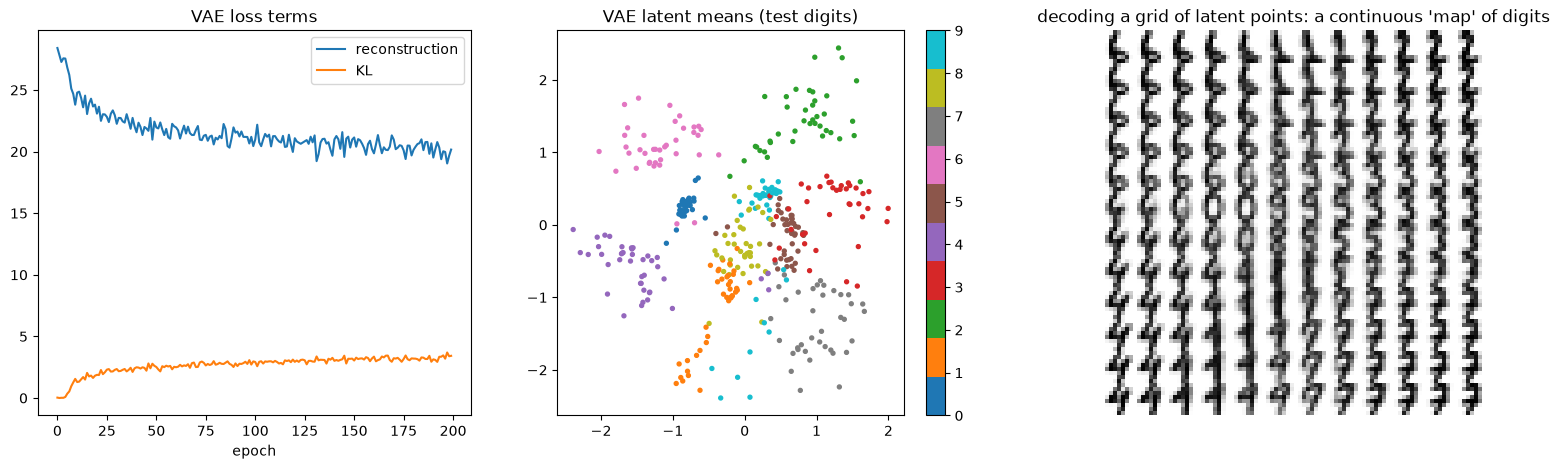

In [5]:
class VAE(nn.Module):
    def __init__(self, d_in=64, d_z=2, h=256):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU()); self.mu = nn.Linear(h, d_z); self.logvar = nn.Linear(h, d_z)
        self.dec = nn.Sequential(nn.Linear(d_z, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, d_in))      # logits (Bernoulli likelihood)
    def forward(self, x):
        h = self.enc(x); mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)                                          # reparameterisation trick
        return self.dec(z), mu, logvar

def vae_loss(logits, x, mu, logvar, beta=1.0):
    rec = F.binary_cross_entropy_with_logits(logits, x, reduction="sum") / len(x)
    kl = -0.5 * torch.sum(1 + logvar - mu ** 2 - logvar.exp()) / len(x)
    return rec + beta * kl, rec, kl

def train_vae(d_z=2, beta=1.0, epochs=200):
    torch.manual_seed(0); m = VAE(d_z=d_z); o = torch.optim.Adam(m.parameters(), 1e-3); hist = []
    for ep in range(epochs):
        for (xb,) in dl:
            logits, mu, logvar = m(xb); loss, rec, kl = vae_loss(logits, xb, mu, logvar, beta)
            o.zero_grad(); loss.backward(); o.step()
        hist.append((rec.item(), kl.item()))
    return m, np.array(hist)

vae, vh = train_vae(d_z=2)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].plot(vh[:, 0], label="reconstruction"); axes[0].plot(vh[:, 1], label="KL"); axes[0].legend(); axes[0].set(title="VAE loss terms", xlabel="epoch")
with torch.no_grad(): mu_te = vae.mu(vae.enc(torch.tensor(X_te))).numpy()
sc = axes[1].scatter(*mu_te.T, c=y_te, cmap="tab10", s=8); axes[1].set_title("VAE latent means (test digits)"); fig.colorbar(sc, ax=axes[1])
grid = np.linspace(-2.5, 2.5, 12); canvas = np.zeros((8 * 12, 8 * 12))
with torch.no_grad():
    for i, a in enumerate(grid):
        for j, b in enumerate(grid):
            canvas[i * 8:(i + 1) * 8, j * 8:(j + 1) * 8] = torch.sigmoid(vae.dec(torch.tensor([[b, -a]], dtype=torch.float32))).numpy().reshape(8, 8)
axes[2].imshow(canvas, cmap="gray_r"); axes[2].set_title("decoding a grid of latent points: a continuous 'map' of digits"); axes[2].axis("off")
plt.show()

## **5. Generating New Samples and Interpolating**

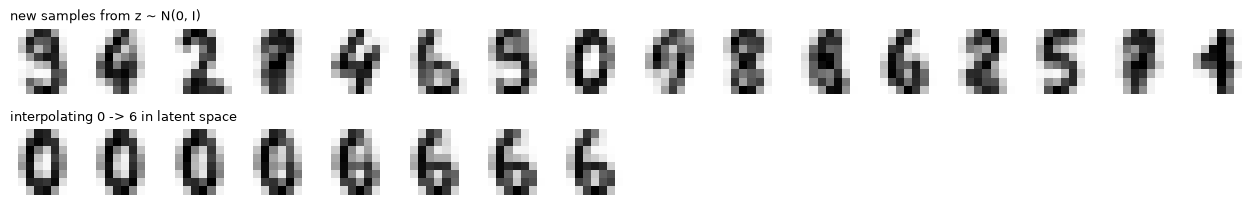

In [6]:
vae8, _ = train_vae(d_z=8)
with torch.no_grad():
    samples = torch.sigmoid(vae8.dec(torch.randn(16, 8))).numpy()
    za, zb = vae8.mu(vae8.enc(torch.tensor(X_te[y_te == 0][:1]))), vae8.mu(vae8.enc(torch.tensor(X_te[y_te == 6][:1])))
    interp = torch.sigmoid(vae8.dec(torch.cat([za + t * (zb - za) for t in np.linspace(0, 1, 8)]))).numpy()
fig, axes = plt.subplots(2, 16, figsize=(16, 2.4))
for j in range(16): axes[0, j].imshow(samples[j].reshape(8, 8), cmap="gray_r"); axes[0, j].axis("off")
for j in range(16): axes[1, j].axis("off")
for j in range(8): axes[1, j].imshow(interp[j].reshape(8, 8), cmap="gray_r")
axes[0, 0].set_title("new samples from z ~ N(0, I)", loc="left", fontsize=9); axes[1, 0].set_title("interpolating 0 -> 6 in latent space", loc="left", fontsize=9)
plt.show()

# **Part 2: Going Deeper**

### beta-VAE: trading reconstruction for a smoother latent space
$\beta > 1$ weights the KL term more: more regular, more **disentangled** latent factors (Higgins et al., 2017) but blurrier reconstructions. $\beta < 1$: sharper reconstructions, less regular latent space. Too strong a decoder or KL weight can cause **posterior collapse** (the decoder ignores $\mathbf z$; KL -> 0).

In [7]:
rows = []
for beta in [0.2, 1.0, 4.0]:
    m_, h_ = train_vae(d_z=8, beta=beta, epochs=120)
    rows.append({"beta": beta, "reconstruction loss": h_[-1, 0], "KL": h_[-1, 1]})
pd.DataFrame(rows).set_index("beta").round(2)

,reconstruction loss,KL
beta,,
0.2,16.69,10.41
1.0,20.79,3.62
4.0,27.15,0.00


### Uses in science and remote sensing
- Compressing hyperspectral data; spectral unmixing with autoencoders.
- Anomaly / change detection by reconstruction error.
- Conditional VAEs for **gap-filling** (clouds) and data augmentation.
- VAE encoders compress images into the latent space where **latent diffusion** models (Day 73) operate.

## **Practice Problems**
1. Train a **linear** autoencoder (no ReLUs, no sigmoid) with d_z = 8 and compare its reconstruction error with PCA(8).
2. Use the 2-D VAE latent means + k-NN to classify digits. How good is a 2-D unsupervised code?
3. Set the anomaly threshold at the 99th percentile of training reconstruction errors. Report precision and recall on the test spectra.
4. *(Advanced)* Build a **conditional VAE** (concatenate a one-hot digit label to the encoder input and decoder input) and generate one sample of each digit.

linear AE 0.0289 vs PCA 0.0250
5-NN on 2-D VAE codes: 0.844
threshold 1.78e-04: precision 0.952, recall 1.000


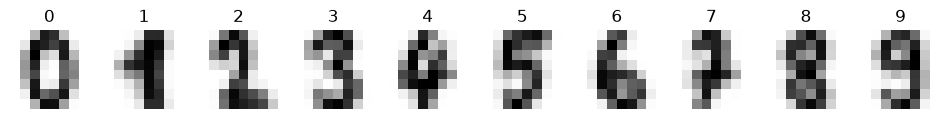

In [8]:
# Solution 1
lin = nn.Sequential(nn.Linear(64, 8), nn.Linear(8, 64)); o = torch.optim.Adam(lin.parameters(), 3e-3)
for ep in range(400):
    l_ = F.mse_loss(lin(torch.tensor(X_tr)), torch.tensor(X_tr)); o.zero_grad(); l_.backward(); o.step()
pca8 = PCA(8).fit(X_tr)
with torch.no_grad(): print(f"linear AE {F.mse_loss(lin(torch.tensor(X_te)), torch.tensor(X_te)).item():.4f} vs PCA {np.mean((pca8.inverse_transform(pca8.transform(X_te)) - X_te) ** 2):.4f}")
# Solution 2
from sklearn.neighbors import KNeighborsClassifier
with torch.no_grad(): mu_tr = vae.mu(vae.enc(torch.tensor(X_tr))).numpy()
print("5-NN on 2-D VAE codes:", round(KNeighborsClassifier(5).fit(mu_tr, y_tr).score(mu_te, y_te), 3))
# Solution 3
with torch.no_grad(): err_tr = ((spec_ae(torch.tensor(normal_tr))[0] - torch.tensor(normal_tr)) ** 2).mean(1).numpy()
thr = np.percentile(err_tr, 99); flag = err > thr
print(f"threshold {thr:.2e}: precision {test_lab[flag].mean():.3f}, recall {flag[test_lab == 1].mean():.3f}")
# Solution 4
class CVAE(VAE):
    def __init__(self, d_z=8):
        super().__init__(d_in=64 + 10, d_z=d_z); self.dec[0] = nn.Linear(d_z + 10, 256); self.dec[-1] = nn.Linear(256, 64)
    def forward(self, x, c):
        h = self.enc(torch.cat([x, c], 1)); mu, logvar = self.mu(h), self.logvar(h); z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.dec(torch.cat([z, c], 1)), mu, logvar
torch.manual_seed(0); cv = CVAE(); o = torch.optim.Adam(cv.parameters(), 1e-3)
Xt_, Ct_ = torch.tensor(X_tr), F.one_hot(torch.tensor(y_tr), 10).float()
for ep in range(150):
    for idx in torch.randperm(len(Xt_)).split(64):
        lg, mu_, lv_ = cv(Xt_[idx], Ct_[idx]); l_, _, _ = vae_loss(lg, Xt_[idx], mu_, lv_); o.zero_grad(); l_.backward(); o.step()
with torch.no_grad(): gen = torch.sigmoid(cv.dec(torch.cat([torch.randn(10, 8), torch.eye(10)], 1))).numpy()
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for j in range(10): axes[j].imshow(gen[j].reshape(8, 8), cmap="gray_r"); axes[j].axis("off"); axes[j].set_title(str(j))
plt.show()

## **Key References**
- Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with neural networks. *Science*, 313(5786), 504-507.
- Vincent, P., Larochelle, H., Bengio, Y., & Manzagol, P.-A. (2008). Extracting and composing robust features with denoising autoencoders. *ICML 2008*.
- Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *ICLR 2014*.
- Higgins, I. et al. (2017). beta-VAE: Learning basic visual concepts with a constrained variational framework. *ICLR 2017*.
- Sohn, K., Lee, H., & Yan, X. (2015). Learning structured output representation using deep conditional generative models. *NeurIPS 28*.
- Kingma, D. P., & Welling, M. (2019). An introduction to variational autoencoders. *Foundations and Trends in Machine Learning*, 12(4), 307-392.